# corrlib showcase

Six questions, one library.

1. What does correlation actually measure, and when does the number lie?
2. Do two things crash together, and is that a different question from correlation? (yes)
3. Why does a correlation vanish when you measure it too often?
4. How much of a correlation matrix is real, and what do you do about the rest?
5. What is left once the shared influence - the market, the economy - is taken out?
6. If many sensors record the same signal, what is the best way to combine them?

Sections 1-4 use the library one piece at a time, to show what each piece does. Section 5
uses the `Correlator`, which chains them for an application in a few lines.

Everything runs on real market data pulled with `yfinance`. Where the point needs data
where the true answer is known in advance, the notebook simulates it and says so.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import corrlib
from corrlib import correlation_measures as cm
from corrlib import sampling_estimators as se
from corrlib import random_matrix_cleaning as rmt
from corrlib import array_stacking as stack
from corrlib import Correlator, plotting

#house style, keeps every figure in the portfolio looking like the same body of work
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

## Getting the data

Forty US names across several sectors, ten years of daily closes. Sectors matter here -
a universe of forty tech stocks would have one enormous eigenvalue and nothing else to
look at, which would make the random matrix section boring.

In [2]:
#spread across sectors on purpose, so there is real block structure to find
TICKERS = ['XOM','CVX','COP','SLB','OXY',            # energy
           'JPM','BAC','GS','MS','C',                # banks
           'AAPL','MSFT','NVDA','GOOGL','META',      # tech
           'JNJ','PFE','MRK','ABBV','UNH',           # healthcare
           'PG','KO','PEP','WMT','COST',             # staples
           'CAT','BA','GE','HON','UNP',              # industrials
           'NEE','DUK','SO','D','AEP',               # utilities
           'AMT','PLD','SPG','O','EQR']              # property

raw = yf.download(TICKERS, start='2015-01-01', end='2025-01-01', progress=False)['Close']
raw = raw.dropna(axis=1, how='any')                  # drop any ticker with gaps
returns = np.log(raw).diff().dropna()                # log returns

#corrlib wants variables down the rows, observations across - so transpose
X = returns.values.T
names = list(returns.columns)

print(f"{X.shape[0]} tickers, {X.shape[1]} days")
print(f"q = variables/observations = {X.shape[0]/X.shape[1]:.3f}   (small is good)")

C:\Users\kevin\AppData\Local\Temp\ipykernel_25976\1847212151.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(TICKERS, start='2015-01-01', end='2025-01-01', progress=False)['Close']



1 Failed download:


['EQR']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735707600")')


39 tickers, 2515 days
q = variables/observations = 0.016   (small is good)


## 1. Same number, different reality

Correlation compresses a whole relationship into one number, and four completely
different data sets can give the same one.

The panels below all have a Pearson correlation near 0.6:

- an honest tilted cloud
- **no** relationship at all, with twelve extreme days creating the whole thing
- two separate groups, neither correlated internally
- a real relationship whose spread widens as things get larger

The tail dependence printed next to each is the number from section 2, and it already
separates them.

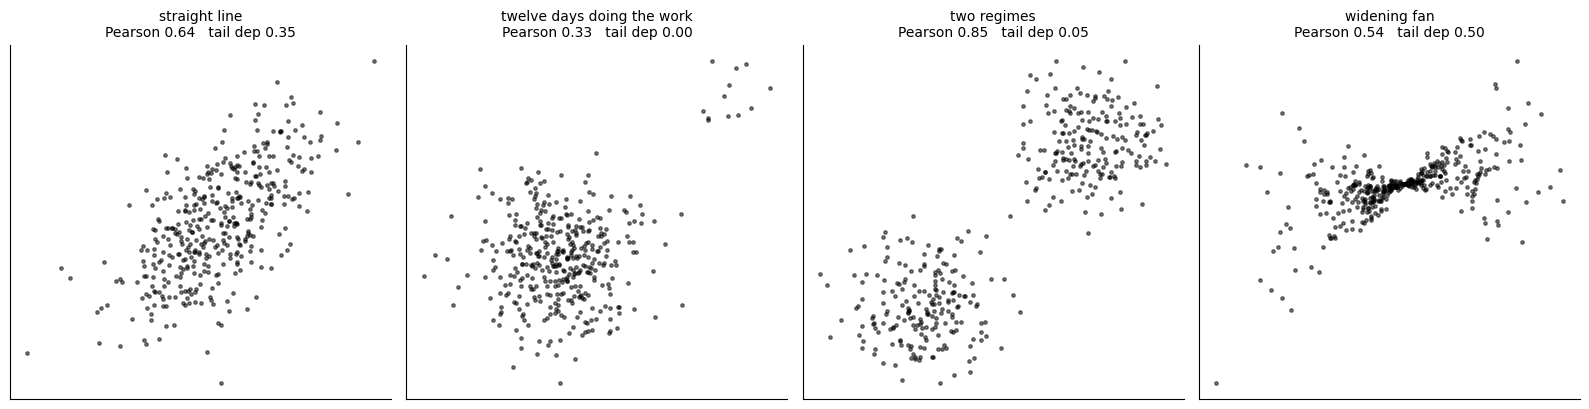

In [3]:
cm.plot_same_number_different_reality(target=0.6)
plt.show()

### The same problem on the real data

Pearson against Spearman. Pearson uses the values, Spearman uses only their ordering, so
one extreme day can move Pearson a long way and can barely move Spearman.

Pairs sitting well off the diagonal are pairs whose correlation is being driven by a
handful of days.

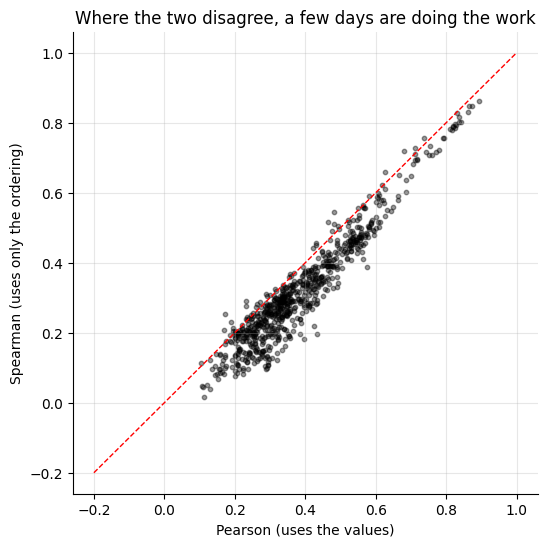

biggest disagreement: CVX and O
  Pearson 0.43   Spearman 0.20


In [4]:
C_pearson = cm.pearson(X)
C_spearman = cm.spearman(X)

#upper triangle only, so each pair is counted once
iu = np.triu_indices(len(names), k=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(C_pearson[iu], C_spearman[iu], s=10, alpha=0.4, color='k')
ax.plot([-0.2, 1], [-0.2, 1], 'r--', lw=1)           # where they would agree exactly
ax.set_xlabel('Pearson (uses the values)')
ax.set_ylabel('Spearman (uses only the ordering)')
ax.set_title('Where the two disagree, a few days are doing the work')
plt.show()

gap = np.abs(C_pearson - C_spearman)
i, j = np.unravel_index(np.argmax(np.triu(gap, 1)), gap.shape)
print(f"biggest disagreement: {names[i]} and {names[j]}")
print(f"  Pearson {C_pearson[i,j]:.2f}   Spearman {C_spearman[i,j]:.2f}")

## 2. Crashing together is a different question

Correlation describes an average day. Risk is about the bad ones.

**Tail dependence:** take the worst 5% of days for asset A. What fraction of those were
also in the worst 5% for asset B? If they were independent you would get 5% back.

The curve pushes further and further into the tail. If it settles somewhere positive, the
two genuinely go down together. If it slides toward zero, they do not, and correlation was
overstating the joint risk.

Two pairs below: two banks, and a bank against a utility.

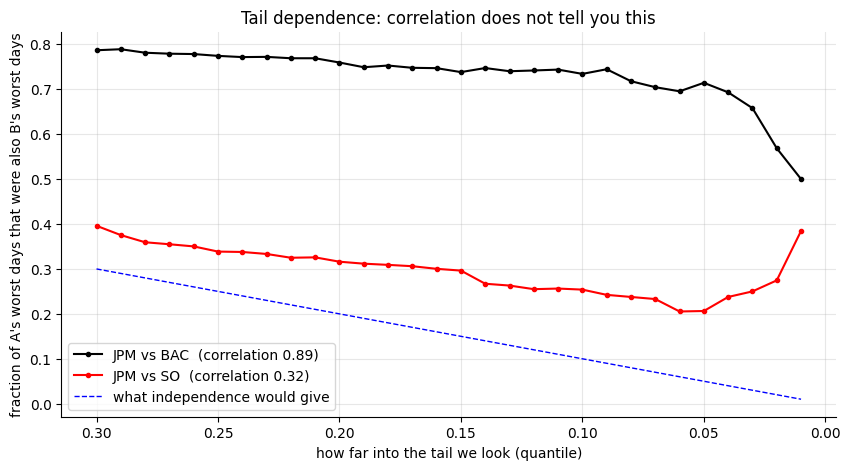

In [5]:
pair_same = ('JPM', 'BAC')                           # two banks
pair_diff = ('JPM', 'SO')                            # a bank and a utility

fig, ax = plt.subplots(figsize=(10, 5))
for pair, colour in [(pair_same, 'k'), (pair_diff, 'r')]:
    a = returns[pair[0]].values
    b = returns[pair[1]].values
    q, chi = cm.chi_curve(a, b)
    r = cm.pearson(np.vstack([a, b]))[0, 1]
    ax.plot(q, chi, 'o-', ms=3, color=colour,
            label=f"{pair[0]} vs {pair[1]}  (correlation {r:.2f})")

ax.plot(np.linspace(0.30, 0.01, 30), np.linspace(0.30, 0.01, 30), 'b--', lw=1,
        label='what independence would give')
ax.invert_xaxis()                                    # further into the tail to the right
ax.set_xlabel('how far into the tail we look (quantile)')
ax.set_ylabel('fraction of A\'s worst days that were also B\'s worst days')
ax.set_title('Tail dependence: correlation does not tell you this')
ax.legend()
plt.show()

## 3. The Epps effect

Measure a correlation second by second and it disappears. Measure it daily and it comes
back. The market did not change - the measurement did.

The reason: two assets do not trade at the same instant. Sample very fast and you keep
catching one just after it moved and the other just before, so the two look unrelated.

First on simulated ticks, because there the true correlation is known (0.7) and the
collapse can be measured against it.

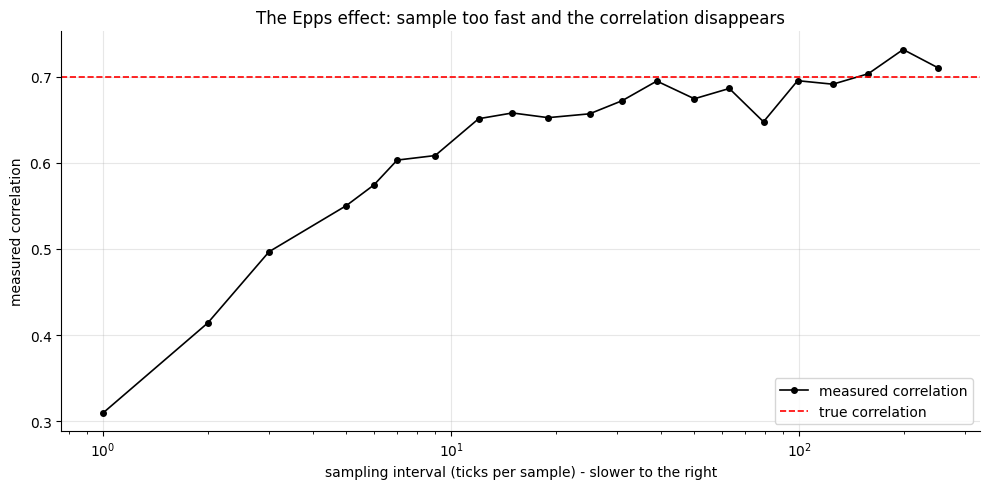

sampling every tick:      correlation 0.310
sampling every 251 ticks:  correlation 0.710
the truth:                correlation 0.700


In [6]:
#two price paths built with a known correlation of 0.7, then hidden behind the two
#problems real tick data has - a small random error on every printed price, and trades
#arriving at irregular times
noisy_prices, true_prices = se.simulate_noisy_ticks(n=30000, true_correlation=0.7)

se.plot_epps_curve(noisy_prices, true_correlation=0.7)
plt.show()

steps, corr = se.epps_curve(noisy_prices)
print(f"sampling every tick:      correlation {corr[0]:.3f}")
print(f"sampling every {steps[-1]} ticks:  correlation {corr[-1]:.3f}")
print(f"the truth:                correlation 0.700")

### Hayashi-Yoshida: the fix

Rather than forcing the two series onto a shared clock, work from the raw timestamps.
Take every return of asset A and every return of asset B, and if their time intervals
**overlap**, multiply them into the total. If they do not overlap, ignore the pair.

No grid, no interpolation, no Epps bias.

In [7]:
#irregular arrival times - each asset trades at its own random moments
rng = np.random.default_rng(3)
n = noisy_prices.shape[1]
t = np.arange(n, dtype=float)

keep_1 = np.sort(rng.choice(n, size=n // 3, replace=False))    # asset 1 trades a third of the time
keep_2 = np.sort(rng.choice(n, size=n // 3, replace=False))    # asset 2, different moments

hy = se.hayashi_yoshida(t[keep_1], noisy_prices[0, keep_1],
                        t[keep_2], noisy_prices[1, keep_2])

#turn the covariance into a correlation using each asset's own variation
v1 = np.sum(np.diff(np.log(noisy_prices[0, keep_1]))**2)
v2 = np.sum(np.diff(np.log(noisy_prices[1, keep_2]))**2)
print(f"Hayashi-Yoshida on irregular ticks: {hy/np.sqrt(v1*v2):.3f}")
print(f"plain method on the same data:      {se.epps_curve(noisy_prices)[1][0]:.3f}")
print(f"the truth:                          0.700")
print("\nit recovers most of the gap, not all of it - subsampling throws away")
print("information that no estimator can put back")

Hayashi-Yoshida on irregular ticks: 0.496
plain method on the same data:      0.310
the truth:                          0.700

it recovers most of the gap, not all of it - subsampling throws away
information that no estimator can put back


### And on real intraday data

`yfinance` gives one-minute bars for the last month, which is enough to see the curve
bend. There is no known true answer here, so the daily correlation stands in for it -
which is itself an assumption worth stating rather than hiding.

C:\Users\kevin\AppData\Local\Temp\ipykernel_25976\3127641230.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  intraday = yf.download(['JPM', 'BAC'], period='5d', interval='1m', progress=False)['Close']


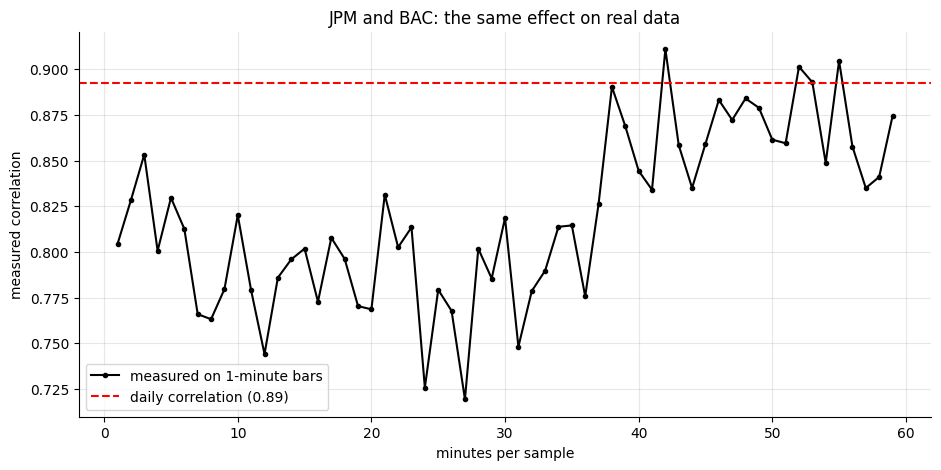

In [8]:
intraday = yf.download(['JPM', 'BAC'], period='5d', interval='1m', progress=False)['Close']
intraday = intraday.dropna()
P = intraday.values.T                                # shape (2, n_minutes)

steps, corr = se.epps_curve(P, steps=np.arange(1, 60))
daily = cm.pearson(np.vstack([returns['JPM'].values, returns['BAC'].values]))[0, 1]

fig, ax = plt.subplots()
ax.plot(steps, corr, 'o-', color='k', ms=3, label='measured on 1-minute bars')
ax.axhline(daily, color='r', ls='--', label=f'daily correlation ({daily:.2f})')
ax.set_xlabel('minutes per sample')
ax.set_ylabel('measured correlation')
ax.set_title('JPM and BAC: the same effect on real data')
ax.legend()
plt.show()

## 4. How much of the matrix is real?

Forty assets means 780 pairwise correlations to estimate. From 2,500 days that is
comfortable. From 250 days it is not, and most of what comes out is noise.

Random matrix theory says exactly what the eigenvalues look like when there is genuinely
**nothing** there - they fall inside a band with hard edges and nowhere else. So anything
inside the band can be treated as noise, and anything outside it is probably real.

Below: the measured spectrum against that prediction. The one eigenvalue far off to the
right is the market itself, moving everything together.

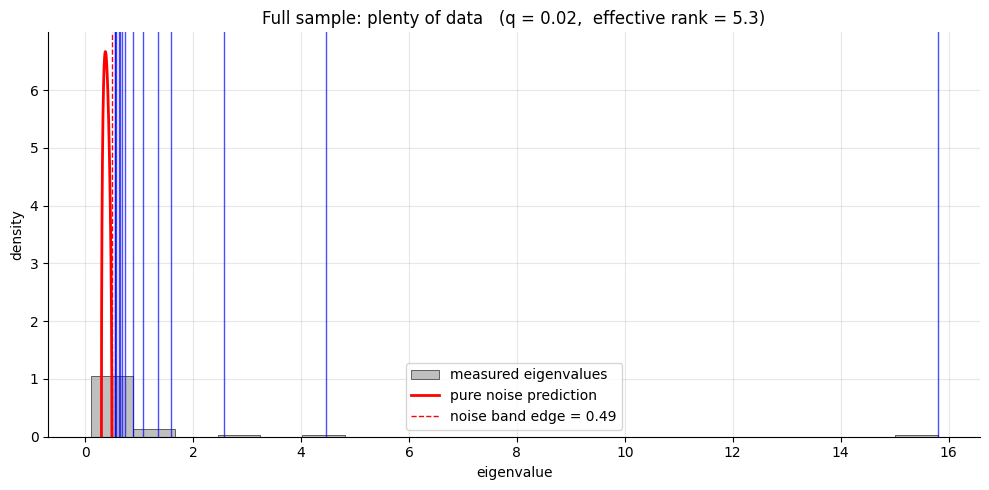

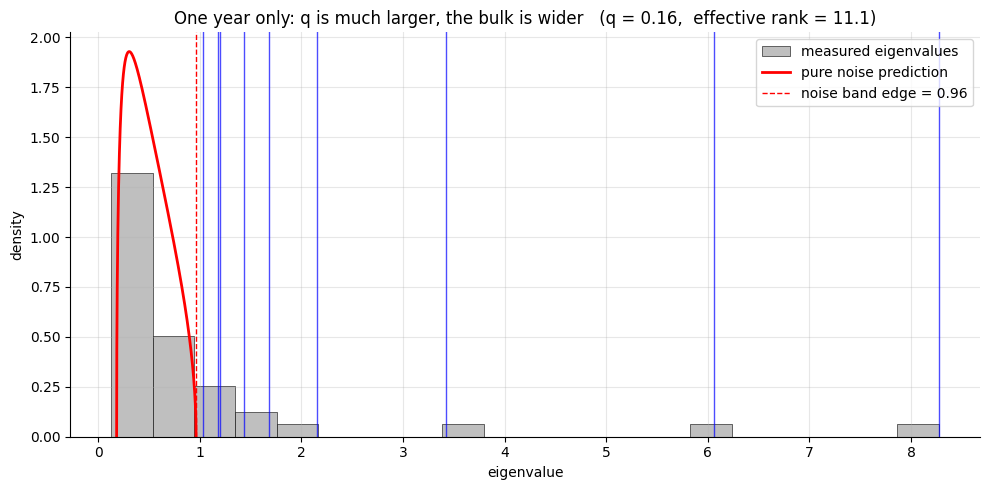

In [9]:
C = cm.pearson(X)
T = X.shape[1]

rmt.plot_spectrum(C, T, title='Full sample: plenty of data')
plt.show()

#now the realistic case - one year of data for forty assets
X_short = X[:, -250:]
C_short = cm.pearson(X_short)

rmt.plot_spectrum(C_short, 250, title='One year only: q is much larger, the bulk is wider')
plt.show()

### The four cleaners

- **raw** - do nothing, the baseline
- **clipped** - everything inside the noise band replaced by one flat value
- **linear shrinkage** (Ledoit-Wolf) - pull every eigenvalue the same fraction toward the
  average, with the fraction estimated from the data rather than guessed
- **nonlinear shrinkage** - pull each one by its own amount, set by how trustworthy its
  eigenvector is. This is the current standard and the only one that uses the fact that
  the eigenvectors are noisy too, not just the eigenvalues. Implemented with Ledoit and
  Wolf's 2020 analytical estimator, which the test suite shows beats raw at every ratio
  of variables to observations tried.

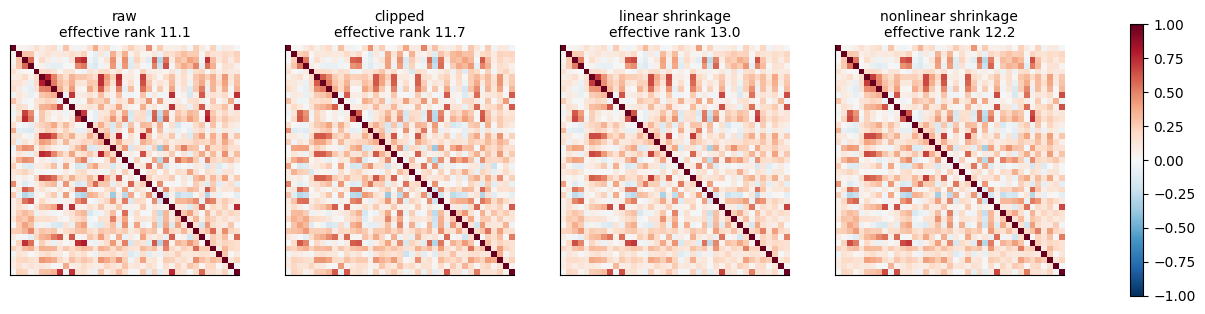

raw                    effective number of independent bets:  11.1
clipped                effective number of independent bets:  11.7
linear shrinkage       effective number of independent bets:  13.0
nonlinear shrinkage    effective number of independent bets:  12.2


In [10]:
rmt.plot_cleaner_comparison(C_short, 250, X=X_short)
plt.show()

for name, M in [('raw', C_short),
                ('clipped', rmt.clip(C_short, 250)),
                ('linear shrinkage', rmt.linear_shrinkage(C_short, 250, X=X_short)),
                ('nonlinear shrinkage', rmt.nonlinear_shrinkage(C_short, 250))]:
    print(f"{name:22s} effective number of independent bets: {rmt.effective_rank(M):5.1f}")

### The honest test

A cleaner matrix is not the point. The point is whether it makes a better decision.

The test everyone uses: build a minimum-variance portfolio from each matrix, then compare
what it **predicted** its risk would be against what it actually **realised** out of
sample.

Sample covariance is known to understate realised risk badly - the optimiser finds
combinations that looked safe in-sample purely by chance. Closing that gap is the entire
purpose of cleaning.

A ratio of 1.0 is honest. Above 1.0 means the portfolio was riskier than it claimed.

In [11]:
#fit on one year, hold for the next year, repeat down the whole history
window = 250
hold = 250
methods = ['raw', 'clip', 'linear_shrinkage', 'nonlinear_shrinkage']
results = {m: {'predicted': [], 'realised': []} for m in methods}

for start in range(0, X.shape[1] - window - hold, hold):
    train = X[:, start:start + window]
    test = X[:, start + window:start + window + hold]

    C_train = np.cov(train)
    for method in methods:
        w = stack.min_variance(C_train, clean=method, n_observations=window, X=train)

        predicted = np.sqrt(w @ C_train @ w * 252)           # risk the model claimed
        realised = (w @ test).std() * np.sqrt(252)           # risk that actually happened
        results[method]['predicted'].append(predicted)
        results[method]['realised'].append(realised)

print(f"{'method':22s} {'predicted':>10s} {'realised':>10s} {'ratio':>8s}")
for method in methods:
    p = np.mean(results[method]['predicted'])
    r = np.mean(results[method]['realised'])
    print(f"{method:22s} {p:10.3f} {r:10.3f} {r/p:8.2f}")

method                  predicted   realised    ratio
raw                         0.103      0.152     1.48
clip                        0.109      0.156     1.43
linear_shrinkage            0.105      0.147     1.40
nonlinear_shrinkage         0.104      0.149     1.43


Every cleaner closes part of the gap between the risk a portfolio claimed and the risk it
delivered; none closes all of it. That is the honest result, and it matches the published
one: Bongiorno and Challet (2023) show nonlinear shrinkage, the best estimator of the
*matrix*, is far from optimal for *portfolios*, because a minimum-variance optimiser
leans hardest on exactly the small eigenvalues that are hardest to estimate.

Worth recording: an earlier version of this library showed clipping closing the gap
almost perfectly. That turned out to be a bug - clipping was applying a unit-variance
noise band to a covariance matrix of daily returns, so it flattened almost everything and
quietly produced a near equal-weight portfolio. The test suite now checks that every
cleaner gives the same answer on a covariance as on the matching correlation.

## 5. Taking out the market

Two bank stocks are correlated. Is that a bank thing, or is it just that the whole economy
moves both of them? Most of what is in a stock correlation matrix is the second: on a bad
day for the economy almost everything falls together, and that single shared movement
swamps the structure underneath.

Two ways to take it out:

- **regress out a known factor** - here, the market's own daily return (the equal-weighted
  average of the forty). Each stock gets its own loading on it, and what is left is the
  part the market cannot explain.
- **remove the top mode** - don't name the factor at all. The strongest pattern of joint
  movement is the top eigenvector; take it out.

Each has a cost the noise theory has to know about. Regressing out one factor spends one
**observation**. Removing one mode spends one **variable** - the leftover matrix has one
fewer dimension. The `Correlator` tracks both and adjusts the noise band, so the cleaning
step does not mistake what is left for noise or signal.

Three configurations of the same object, each one line:

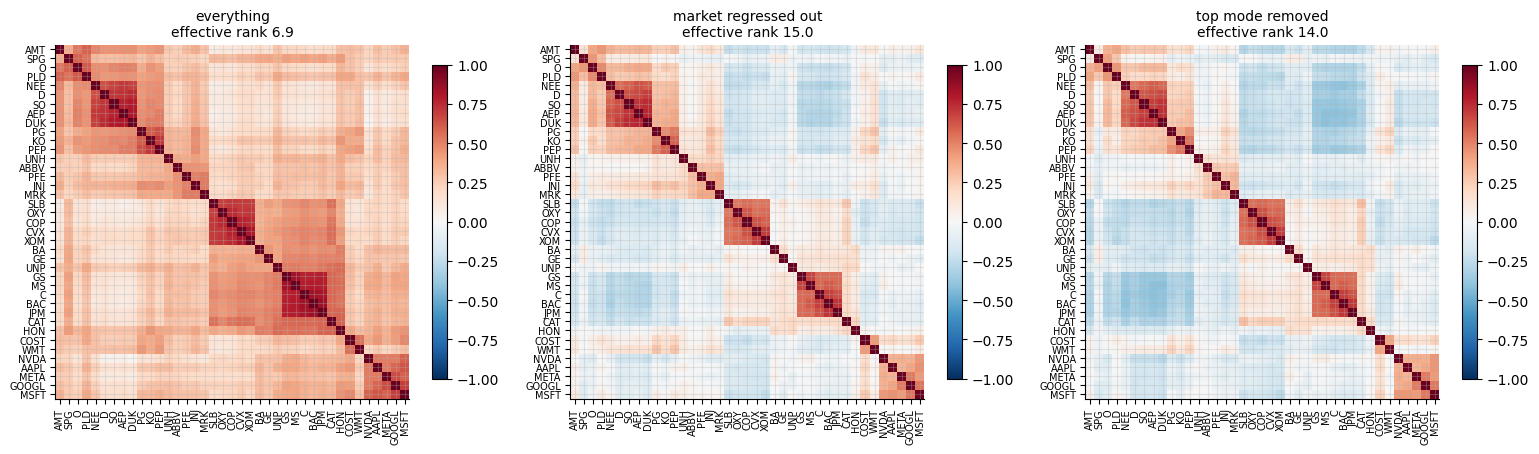

,measure,removed,clean,robust,n_variables,n_observations,n_effective,q,effective_rank_measured,effective_rank_final
everything,spearman,nothing,nonlinear_shrinkage,False,39,2515,2515.0,0.016,6.82,6.86
market regressed out,spearman,1 factor,nonlinear_shrinkage,False,39,2515,2514.0,0.016,6.82,15.03
top mode removed,spearman,1 mode,nonlinear_shrinkage,False,39,2515,2515.0,0.015,6.82,13.96


In [12]:
#the market's daily return: the equal-weighted average of the forty stocks
market = X.mean(axis=0)

configs = {
    'everything':           Correlator(measure='spearman', clean='nonlinear_shrinkage'),
    'market regressed out': Correlator(measure='spearman', remove=[market], clean='nonlinear_shrinkage'),
    'top mode removed':     Correlator(measure='spearman', remove=1, clean='nonlinear_shrinkage'),
}
matrices = {label: c.fit(X, labels=names) for label, c in configs.items()}

plotting.compare(list(matrices.values()), list(matrices), labels=names)
plt.show()

pd.DataFrame({label: c.summary() for label, c in configs.items()}).T

Re-ordered by clustering, the sectors appear as squares down the diagonal once the market
is out. With the market left in, everything is warm and the blocks sit on top of a big
shared offset. The effective rank - how many independent bets the forty stocks really
offer - rises once the market is out, because the market was the one bet everything had
in common.

**Is the top mode the market?** The `Correlator` keeps the time series of every mode it
removes, so the question can be checked directly rather than assumed.

In [13]:
top_mode = configs['top mode removed'].mode_series_[0]
print(f"correlation between the top mode and the market return: {abs(np.corrcoef(top_mode, market)[0, 1]):.3f}")

#the price of removing a mode: what is left has to average slightly below zero
residual = configs['top mode removed'].residual_
off_diagonal = residual[~np.eye(len(names), dtype=bool)]
print(f"average leftover correlation: {off_diagonal.mean():+.3f}   "
      f"(roughly -1/(N-1) = {-1/(len(names)-1):+.3f} is what removing a shared mode forces)")

correlation between the top mode and the market return: 0.882
average leftover correlation: -0.026   (roughly -1/(N-1) = -0.026 is what removing a shared mode forces)


The top mode tracks the market closely - a correlation of about 0.9 - without being
told what the market is. Not exactly, because the mode weights each stock by how much it
moves with everything else, while the market average weights them all equally. And
the leftover correlations average slightly negative: not a discovery about the stocks,
just arithmetic. Take out the part everything shares and, on average, what is left has to
lean the other way. That is worth knowing before reading a small negative correlation in
residuals as a hedge.

### The full picture for one configuration

`plot()` gives the standard four panels for any fitted `Correlator`: the measured matrix,
the final one in the same order, the spectrum against the noise band after the market is
out, and the cluster tree.

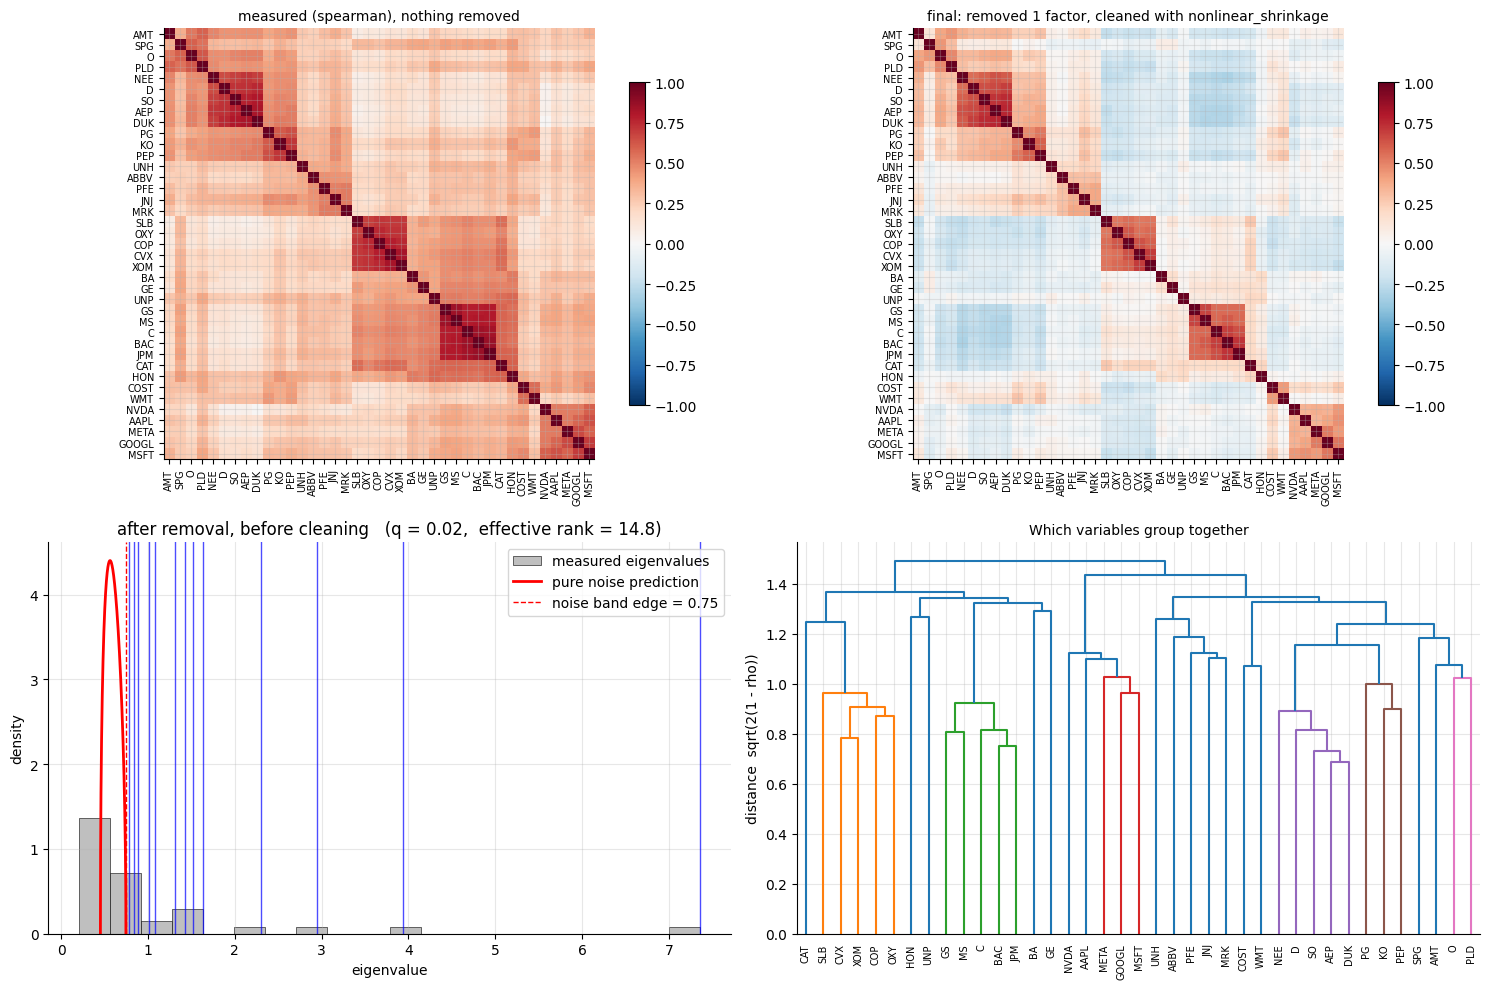

In [14]:
configs['market regressed out'].plot()
plt.show()

With the market out, 13 of the 39 eigenvalues sit beyond the noise band and 8 are well clear
of it - roughly one per sector, which is what the cluster tree shows too. That is the
structure worth keeping; the cleaner shrinks the rest.

Two honest caveats the spectrum shows. The measured bulk is wider than pure noise predicts -
as many eigenvalues fall *below* the band as above it - which is what fat tails and
volatility that changes over ten years do to real returns. And with q this small (2,500
days for 39 stocks), cleaning barely changes the matrix: the final heatmap is almost the
raw one. Cleaning earns its keep when data is short, as section 4 showed with one year.
`robust=True` (Tyler's estimator) is the library's answer to the fat tails.

## 6. Many sensors, one signal

Ten seismometers record the same earthquake plus their own local noise. You want the
earthquake and you have ten noisy copies of it.

Averaging works **if** the noise is independent - with N sensors the noise falls by
sqrt(N). But two stations on the same road share the same traffic, and shared noise
survives averaging exactly as well as the signal does.

So the real question is what weighted combination is best given that the noise is
correlated, and the answer needs a covariance matrix. Which is the whole reason this
belongs in a correlation library.

**And the formula is one you have already seen in this notebook.** The optimal sensor
weights and the minimum-variance portfolio weights from section 4 are the same equation -
derived in array processing in 1969 and in finance in 1952, independently.

In [15]:
#a synthetic array - one shared wave, independent local noise, plus a shared noise source
#(think a motorway running past several stations)
rng = np.random.default_rng(7)
n_samples = 2000
n_sensors = 12

time = np.arange(n_samples)
arrival = 900
wave = np.sin(2*np.pi*(time - arrival)/60) * np.exp(-((time - arrival)/150.0)**2)
wave[time < arrival] = 0                             # nothing before the wave arrives

shared_noise = np.cumsum(rng.normal(0, 0.25, n_samples))      # the motorway, seen by everyone
shared_noise -= shared_noise.mean()

traces = np.array([wave
                   + 1.8*rng.normal(size=n_samples)          # each sensor's own noise
                   + rng.uniform(0.3, 1.2)*shared_noise      # how close each one sits to the road
                   for _ in range(n_sensors)])

NOISE_WINDOW = (0, 700)                              # quiet stretch before the arrival
SIGNAL_WINDOW = (800, 1100)                          # where the wave is

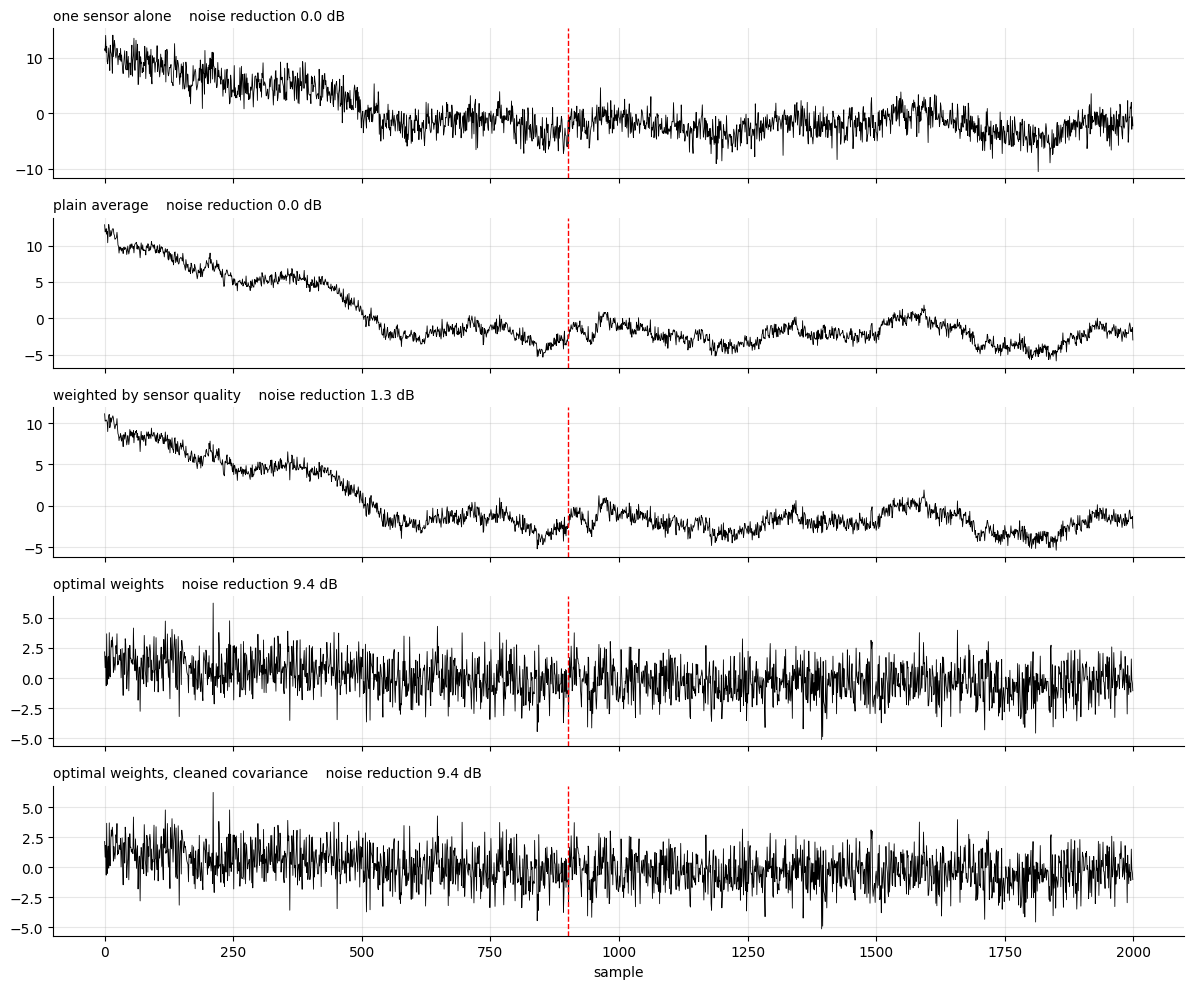

In [16]:
#four ways to combine the same twelve traces.
#the comparison is against a typical single sensor, not the best or worst one,
#so pick the one with the median noise level.
#the optimal weights estimate the noise covariance from the quiet stretch before the
#arrival only - estimated from the whole trace, the method would also suppress the wave
noise_levels = traces[:, NOISE_WINDOW[0]:NOISE_WINDOW[1]].std(axis=1)
single = traces[np.argsort(noise_levels)[len(noise_levels)//2]]
s_simple, w_simple = stack.simple(traces)
s_snr, w_snr = stack.snr_weighted(traces, NOISE_WINDOW, SIGNAL_WINDOW)
s_mvdr, w_mvdr = stack.mvdr(traces, clean=None, noise_window=NOISE_WINDOW)
s_clean, w_clean = stack.mvdr(traces, clean='nonlinear_shrinkage', noise_window=NOISE_WINDOW)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
panels = [('one sensor alone', single), ('plain average', s_simple),
          ('weighted by sensor quality', s_snr), ('optimal weights', s_mvdr),
          ('optimal weights, cleaned covariance', s_clean)]

for ax, (title, trace) in zip(axes, panels):
    ax.plot(time, trace, 'k-', lw=0.6)
    ax.axvline(arrival, color='r', ls='--', lw=1)
    g = stack.gain(trace, single, NOISE_WINDOW)
    ax.set_title(f"{title}    noise reduction {g:.1f} dB", fontsize=10, loc='left')
axes[-1].set_xlabel('sample')
plt.tight_layout()
plt.show()

### Where stacking stops helping

More sensors should mean less noise. With independent noise that works, and the gain
follows the dashed theory line.

It stops working for two different reasons, and they are worth separating:

- **shared noise** - averaging cannot remove something every sensor sees
- **not enough data** - the optimal weights need a covariance matrix, and estimating one
  for many sensors from a short window produces mostly noise, so the weights start to
  chase it

Cleaning the covariance is what holds the second one off.

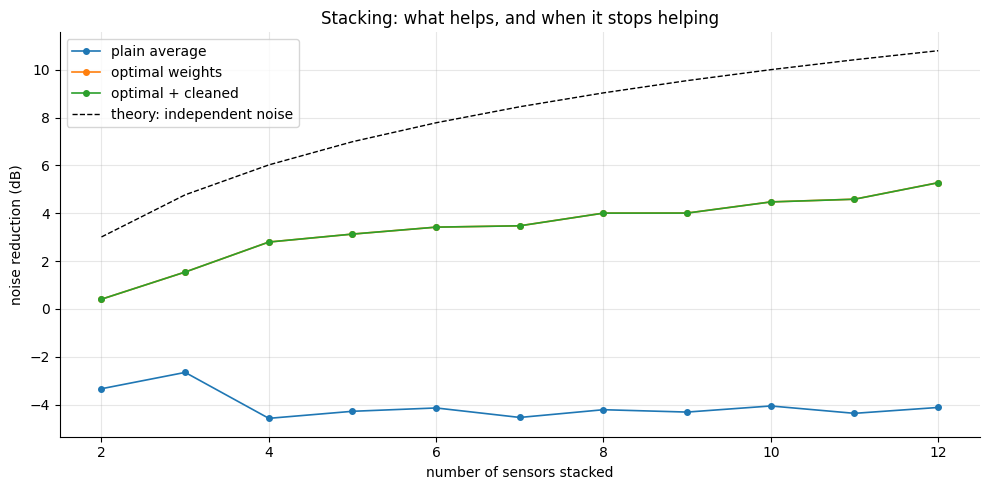

weights chosen by the optimal method:
[ 0.369 -0.082  0.262 -0.352  0.14   0.148 -0.12   0.235 -0.     0.225
 -0.144  0.318]

notice they are not equal - the method downweights the noisier sensors
without ever being told which ones those are


In [17]:
stack.plot_gain_vs_sensors(traces, NOISE_WINDOW, clean='nonlinear_shrinkage')
plt.show()

print("weights chosen by the optimal method:")
print(np.round(w_mvdr, 3))
print("\nnotice they are not equal - the method downweights the noisier sensors")
print("without ever being told which ones those are")

## What this library is for

Everything above gets imported rather than rewritten:

- the **seismic denoiser** uses section 6 in the extract direction - stations in, one
  earthquake out - and section 4 to keep the weights from blowing up
- the **solar project** uses section 6 the other way round - a known weather driver in,
  each site's exposure out - section 5 to take the sun's daily cycle out before measuring
  anything, and the effective rank from section 4 as a measure of how much
  diversification a fleet of farms really has
- the **power volatility project** uses sections 1 and 2, because the question of whether
  weather and price move together is not the same as whether they crash together - and
  section 5, because gas has to come out before weather's effect can be seen

One toolbox, one `Correlator`, three projects. The test suite in `tests/` checks every
method against data where the true answer is known.